In [6]:
# Student Roll No: 24BAD026
# EXPT NO: 6 - IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# -----------------------------------------------------------------------------
# PART A: DATASET PREPARATION AND TEXT PREPROCESSING
# -----------------------------------------------------------------------------
# Student Roll No: 24BAD026
print("=== PART A: DATASET PREPARATION AND TEXT PREPROCESSING ===")

VOCAB_SIZE = 10000
MAX_LEN = 100
EMBEDDING_DIM = 64
ROLL_NO = "24BAD026"

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Load IMDB dataset raw words mapping
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Decode raw sequence back to text for preprocessing demonstration
def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

raw_text_train = [clean_text(decode_review(seq)) for seq in X_train_raw[:5000]]
raw_text_test = [clean_text(decode_review(seq)) for seq in X_test_raw[:1000]]

y_train_sub = y_train[:5000]
y_test_sub = y_test[:1000]

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(raw_text_train)

X_train_seq = tokenizer.texts_to_sequences(raw_text_train)
X_test_seq = tokenizer.texts_to_sequences(raw_text_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Roll No: {ROLL_NO}")
print(f"Training samples: {len(X_train_padded)}, Testing samples: {len(X_test_padded)}")
print(f"Padded train shape: {X_train_padded.shape}")

=== PART A: DATASET PREPARATION AND TEXT PREPROCESSING ===


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Roll No: 24BAD026
Training samples: 5000, Testing samples: 1000
Padded train shape: (5000, 100)


In [2]:

# -----------------------------------------------------------------------------
# PART B: EMBEDDING GENERATION
# -----------------------------------------------------------------------------
# Student Roll No: 24BAD026
print("\n=== PART B: EMBEDDING GENERATION ===")

temp_embedding_layer = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)
sample_embeddings = temp_embedding_layer(X_train_padded[:5])

print(f"Roll No: {ROLL_NO}")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"Embedding Dimension: {EMBEDDING_DIM}")
print(f"Sample Batch Embedding Shape: {sample_embeddings.shape}")



=== PART B: EMBEDDING GENERATION ===
Roll No: 24BAD026
Vocabulary Size: 10000
Embedding Dimension: 64
Sample Batch Embedding Shape: (5, 100, 64)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [3]:
# -----------------------------------------------------------------------------
# PART C: IMPLEMENTING THE LSTM MODEL
# -----------------------------------------------------------------------------
# Student Roll No: 24BAD026
print("\n=== PART C: IMPLEMENTING THE LSTM MODEL ===")

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Roll No: {ROLL_NO}")
model.summary()



=== PART C: IMPLEMENTING THE LSTM MODEL ===
Roll No: 24BAD026


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


=== PART D: MODEL TRAINING AND SENTIMENT PREDICTION ===
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.5122 - loss: 0.6934 - val_accuracy: 0.5190 - val_loss: 0.6925
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.7026 - loss: 0.5869 - val_accuracy: 0.7910 - val_loss: 0.4697
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.8858 - loss: 0.3313 - val_accuracy: 0.8040 - val_loss: 0.4266
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9248 - loss: 0.2646 - val_accuracy: 0.8000 - val_loss: 0.4849
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.9058 - loss: 0.3200 - val_accuracy: 0.7140 - val_loss: 0.6362


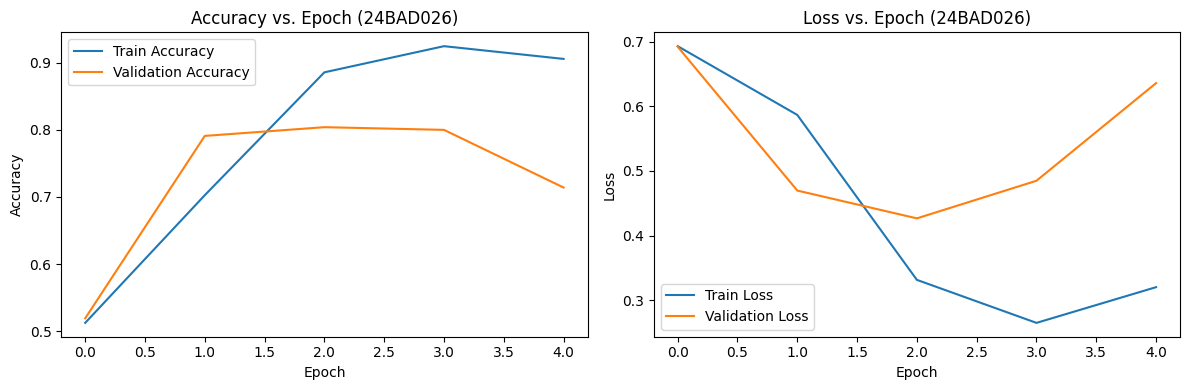

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

--- Evaluation Metrics (24BAD026) ---
Accuracy : 0.7140
Precision: 0.6386
Recall   : 0.9135
F1-Score : 0.7517

Confusion Matrix:
[[281 245]
 [ 41 433]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.53      0.66       526
    Positive       0.64      0.91      0.75       474

    accuracy                           0.71      1000
   macro avg       0.76      0.72      0.71      1000
weighted avg       0.76      0.71      0.70      1000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

--- Sample Sentiment Predictions (24BAD026) ---
Review: 'This movie was absolutely wonderful and brilliant! I loved every scene.'
Predicted Sentiment: Positive (Confidence: 0.8597)

Review: 'Terrible movie, absolute waste of time and complete disaster.'
Predicted Sentiment: Positive (Confidence: 0.8597)



In [4]:

# -----------------------------------------------------------------------------
# PART D: MODEL TRAINING AND SENTIMENT PREDICTION
# -----------------------------------------------------------------------------
# Student Roll No: 24BAD026
print("\n=== PART D: MODEL TRAINING AND SENTIMENT PREDICTION ===")

EPOCHS = 5
BATCH_SIZE = 64

history = model.fit(
    X_train_padded, y_train_sub,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_padded, y_test_sub),
    verbose=1
)

# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Accuracy vs. Epoch ({ROLL_NO})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'Loss vs. Epoch ({ROLL_NO})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluation
y_pred_prob = model.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

acc = accuracy_score(y_test_sub, y_pred)
prec = precision_score(y_test_sub, y_pred)
rec = recall_score(y_test_sub, y_pred)
f1 = f1_score(y_test_sub, y_pred)
cm = confusion_matrix(y_test_sub, y_pred)

print(f"\n--- Evaluation Metrics ({ROLL_NO}) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_sub, y_pred, target_names=['Negative', 'Positive']))

# Sample Predictions
sample_reviews = [
    "This movie was absolutely wonderful and brilliant! I loved every scene.",
    "Terrible movie, absolute waste of time and complete disaster."
]

cleaned_samples = [clean_text(r) for r in sample_reviews]
sample_seqs = tokenizer.texts_to_sequences(cleaned_samples)
sample_padded = pad_sequences(sample_seqs, maxlen=MAX_LEN, padding='post', truncating='post')

sample_preds = model.predict(sample_padded)

print(f"\n--- Sample Sentiment Predictions ({ROLL_NO}) ---")
for text, prob in zip(sample_reviews, sample_preds):
    sentiment = "Positive" if prob > 0.5 else "Negative"
    print(f"Review: '{text}'")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {prob[0]:.4f})\n")